### Loading and Preprocessing Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

file_path = 'data/stroke_prediction_dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
symptoms_raw = df['Symptoms'].fillna('')

drop_cols = ['Patient ID', 'Patient Name', 'Symptoms']
df_struct = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore').copy()

df_struct['Diagnosis'] = df_struct['Diagnosis'].map({'Stroke': 1, 'No Stroke': 0})

if 'Blood Pressure Levels' in df_struct.columns:
    df_struct['BP_Systolic']  = df_struct['Blood Pressure Levels'].str.extract(r'(\d+)/').astype(float)
    df_struct['BP_Diastolic'] = df_struct['Blood Pressure Levels'].str.extract(r'/(\d+)').astype(float)
    df_struct = df_struct.drop(columns=['Blood Pressure Levels'])

if 'Cholesterol Levels' in df_struct.columns:
    df_struct['HDL'] = df_struct['Cholesterol Levels'].str.extract(r'HDL:\s*(\d+)').astype(float)
    df_struct['LDL'] = df_struct['Cholesterol Levels'].str.extract(r'LDL:\s*(\d+)').astype(float)
    df_struct = df_struct.drop(columns=['Cholesterol Levels'])

le = LabelEncoder()
for col in df_struct.select_dtypes(include='object').columns:
    df_struct[col] = le.fit_transform(df_struct[col].astype(str))

df_struct = df_struct.fillna(df_struct.median(numeric_only=True))

### Training & Evaluation

In [ ]:
y = df_struct['Diagnosis'].values
X_struct = df_struct.drop(columns=['Diagnosis']).values

idx = np.arange(len(df_struct))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

y_train, y_test = y[train_idx], y[test_idx]

tfidf = TfidfVectorizer(
    max_features=50,
    token_pattern=r'[^,]+'
)
X_text_train = tfidf.fit_transform(symptoms_raw.iloc[train_idx])
X_text_test  = tfidf.transform(symptoms_raw.iloc[test_idx])

print(f"TF-IDF vocab size   : {len(tfidf.vocabulary_)}")
print(f"Top symptom terms   : {tfidf.get_feature_names_out()[:10]}")

scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct[train_idx])
X_struct_test_scaled  = scaler.transform(X_struct[test_idx])

X_train = sp.hstack([X_text_train, sp.csr_matrix(X_struct_train_scaled)])
X_test  = sp.hstack([X_text_test,  sp.csr_matrix(X_struct_test_scaled)])

print(f"\nCombined train shape : {X_train.shape}")
print(f"Combined test shape  : {X_test.shape}")
print(f"\nClass balance in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {'Stroke' if u == 1 else 'No Stroke'}: {c}")

TF-IDF vocab size   : 20
Top symptom terms   : [' blurred vision' ' confusion' ' difficulty speaking' ' dizziness'
 ' headache' ' loss of balance' ' numbness' ' seizures' ' severe fatigue'
 ' weakness']

Combined train shape : (12000, 40)
Combined test shape  : (3000, 40)

Class balance in test set:
  No Stroke: 1506
  Stroke: 1494


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear Regression':   LinearRegression(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

results = []
cm_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    raw_pred = model.predict(X_test)

    if name == 'Linear Regression':
        y_pred = (raw_pred >= 0.5).astype(int)
    else:
        y_pred = raw_pred.astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
    })
    cm_dict[name] = cm

results_df = pd.DataFrame(results).set_index('Model')
print("Model Evaluation Results (Positive class = Stroke)")
print(results_df.to_string())

print("\nBest per metric:")
for col in results_df.columns:
    best_model = results_df[col].idxmax()
    best_val   = results_df[col].max()
    print(f"  {col:<12}: {best_model} ({best_val:.4f})")


Model Evaluation Results (Positive class = Stroke)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.5010     0.4989  0.4605    0.4789
Linear Regression      0.4983     0.4960  0.4572    0.4758
Decision Tree          0.5050     0.5103  0.1493    0.2310
Random Forest          0.5077     0.5066  0.4357    0.4685
K-Nearest Neighbors    0.4877     0.4858  0.4913    0.4885

Best per metric:
  Accuracy    : Random Forest (0.5077)
  Precision   : Decision Tree (0.5103)
  Recall      : K-Nearest Neighbors (0.4913)
  F1-Score    : K-Nearest Neighbors (0.4885)


### Evaluation Model Comparison

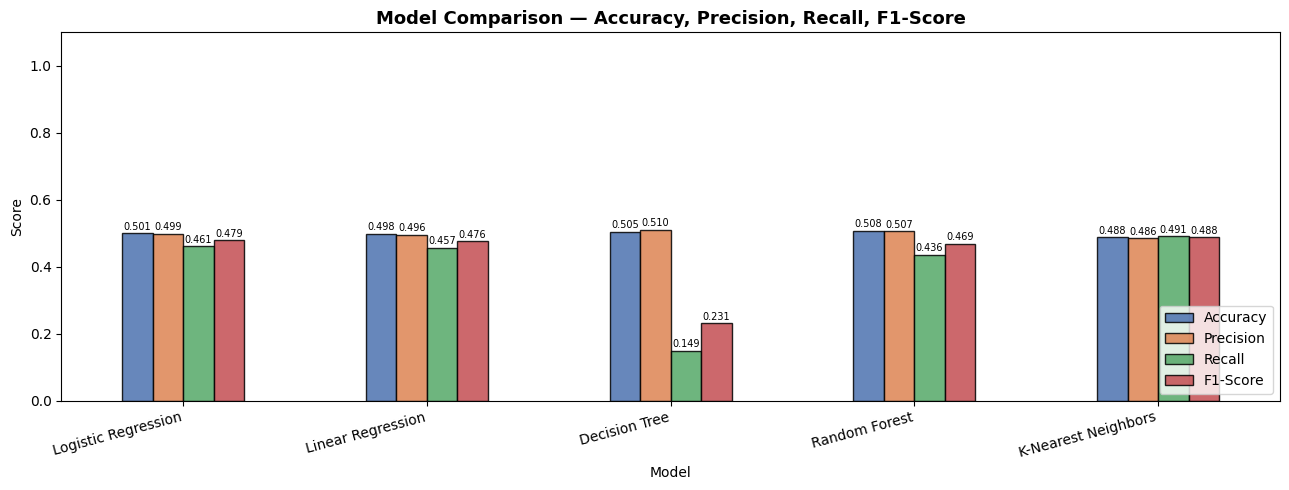

In [ ]:
ax = results_df.plot(
    kind='bar', figsize=(13, 5), ylim=(0, 1.1),
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
    edgecolor='black', alpha=0.85
)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1-Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', fontsize=7, color='black')
plt.tight_layout()
plt.show()